In [1]:
from alpaca.data.historical import StockHistoricalDataClient
import os

API_KEY = os.environ.get("ALPACA_KEY")
SECRET_KEY = os.environ.get("ALPACA_SECRET")


client = StockHistoricalDataClient(api_key=API_KEY, secret_key=SECRET_KEY)

In [2]:
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from datetime import datetime

# Created request params
params = StockBarsRequest(
    symbol_or_symbols=["SPY"],
    timeframe=TimeFrame.Minute,
    start=datetime(2024, 1, 1),
    end=datetime(2026, 5, 1)
)

In [3]:
# Getting the data bars for SPY in DataFrame 
Data = client.get_stock_bars(params)

# Convert to dataframe 
SPY_bars = Data.df

In [4]:
# printing it 
SPY_bars.head()

open    high     low   close   volume  \
symbol timestamp                                                            
SPY    2024-01-02 09:00:00+00:00  476.25  476.36  476.00  476.31  20460.0   
       2024-01-02 09:01:00+00:00  476.34  476.34  476.29  476.29   6369.0   
       2024-01-02 09:02:00+00:00  476.29  476.29  476.28  476.28   6152.0   
       2024-01-02 09:03:00+00:00  476.27  476.27  476.27  476.27    369.0   
       2024-01-02 09:05:00+00:00  476.20  476.20  476.19  476.19    547.0   

                                  trade_count        vwap  
symbol timestamp                                           
SPY    2024-01-02 09:00:00+00:00         84.0  476.301058  
       2024-01-02 09:01:00+00:00         16.0  476.320154  
       2024-01-02 09:02:00+00:00         10.0  476.280164  
       2024-01-02 09:03:00+00:00         10.0  476.270000  
       2024-01-02 09:05:00+00:00          8.0  476.192404

In [5]:
# create a copy of dataset
SPY = SPY_bars.copy()

In [6]:
SPY

open      high     low     close  \
symbol timestamp                                                         
SPY    2024-01-02 09:00:00+00:00  476.2500  476.3600  476.00  476.3100   
       2024-01-02 09:01:00+00:00  476.3400  476.3400  476.29  476.2900   
       2024-01-02 09:02:00+00:00  476.2900  476.2900  476.28  476.2800   
       2024-01-02 09:03:00+00:00  476.2700  476.2700  476.27  476.2700   
       2024-01-02 09:05:00+00:00  476.2000  476.2000  476.19  476.1900   
...                                    ...       ...     ...       ...   
       2026-04-30 23:55:00+00:00  719.9300  719.9300  719.60  719.8610   
       2026-04-30 23:56:00+00:00  719.9000  719.9599  719.65  719.7800   
       2026-04-30 23:57:00+00:00  719.9000  719.9000  719.87  719.8700   
       2026-04-30 23:58:00+00:00  719.9609  719.9700  719.89  719.9167   
       2026-04-30 23:59:00+00:00  719.9000  719.9000  719.81  719.8700   

                                   volume  trade_count        vwap  
symbol timestamp                                                    
SPY    2024-01-02 09:00:00+00:00  20460.0         84.0  476.301058  
       2024-01-02 09:01:00+00:00   6369.0         16.0  476.320154  
       2024-01-02 09:02:00+00:00   6152.0         10.0  476.280164  
       2024-01-02 09:03:00+00:00    369.0         10.0  476.270000  
       2024-01-02 09:05:00+00:00    547.0          8.0  476.192404  
...                                   ...          ...         ...  
       2026-04-30 23:55:00+00:00   8134.0         74.0  719.832431  
       2026-04-30 23:56:00+00:00   1790.0         40.0  719.744147  
       2026-04-30 23:57:00+00:00    278.0         23.0  719.883051  
       2026-04-30 23:58:00+00:00    968.0         17.0  719.942182  
       2026-04-30 23:59:00+00:00   2287.0         43.0  719.861784  

[484617 rows x 7 columns]

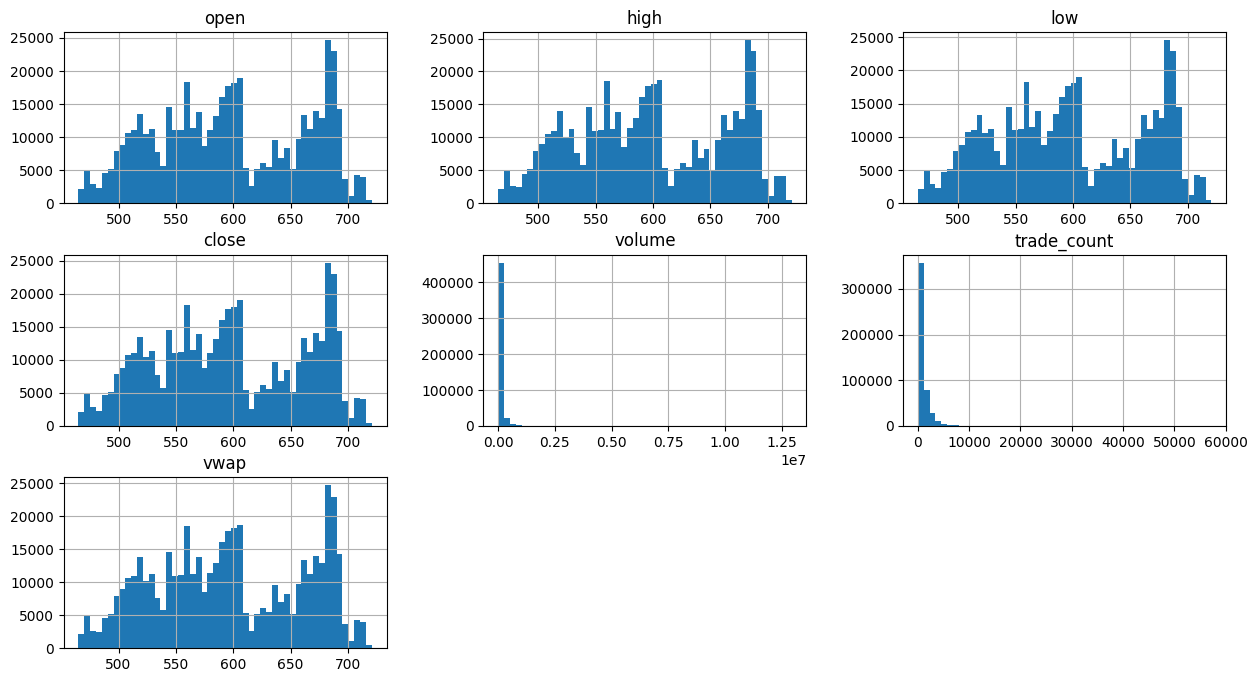

In [7]:
# Visualizing Data
import matplotlib.pyplot as plt
SPY.hist(bins=50, figsize=(15, 8))
plt.show()

In [8]:
# Look for Correlations 
corr_matrix = SPY.corr(numeric_only=True)
corr_matrix["close"].sort_values(ascending=False)

close          1.000000
vwap           0.999998
high           0.999996
low            0.999995
open           0.999995
trade_count    0.125271
volume        -0.000796
Name: close, dtype: float64

In [9]:
# create Target
SPY["TARGET"] = SPY["close"].shift(-1)


In [10]:
SPY

open      high     low     close  \
symbol timestamp                                                         
SPY    2024-01-02 09:00:00+00:00  476.2500  476.3600  476.00  476.3100   
       2024-01-02 09:01:00+00:00  476.3400  476.3400  476.29  476.2900   
       2024-01-02 09:02:00+00:00  476.2900  476.2900  476.28  476.2800   
       2024-01-02 09:03:00+00:00  476.2700  476.2700  476.27  476.2700   
       2024-01-02 09:05:00+00:00  476.2000  476.2000  476.19  476.1900   
...                                    ...       ...     ...       ...   
       2026-04-30 23:55:00+00:00  719.9300  719.9300  719.60  719.8610   
       2026-04-30 23:56:00+00:00  719.9000  719.9599  719.65  719.7800   
       2026-04-30 23:57:00+00:00  719.9000  719.9000  719.87  719.8700   
       2026-04-30 23:58:00+00:00  719.9609  719.9700  719.89  719.9167   
       2026-04-30 23:59:00+00:00  719.9000  719.9000  719.81  719.8700   

                                   volume  trade_count        vwap    TARGET  
symbol timestamp                                                              
SPY    2024-01-02 09:00:00+00:00  20460.0         84.0  476.301058  476.2900  
       2024-01-02 09:01:00+00:00   6369.0         16.0  476.320154  476.2800  
       2024-01-02 09:02:00+00:00   6152.0         10.0  476.280164  476.2700  
       2024-01-02 09:03:00+00:00    369.0         10.0  476.270000  476.1900  
       2024-01-02 09:05:00+00:00    547.0          8.0  476.192404  476.1800  
...                                   ...          ...         ...       ...  
       2026-04-30 23:55:00+00:00   8134.0         74.0  719.832431  719.7800  
       2026-04-30 23:56:00+00:00   1790.0         40.0  719.744147  719.8700  
       2026-04-30 23:57:00+00:00    278.0         23.0  719.883051  719.9167  
       2026-04-30 23:58:00+00:00    968.0         17.0  719.942182  719.8700  
       2026-04-30 23:59:00+00:00   2287.0         43.0  719.861784       NaN  

[484617 rows x 8 columns]

In [11]:
df = SPY.dropna()

In [12]:
X = df.drop("TARGET", axis=1)
y = df["TARGET"]

In [13]:
# split the data into train/test set 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,  y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(
    random_state=42,
    learning_rate=0.01,
    n_estimators=250,
    

)
model.fit(X_train_scaled, y_train)

,loss,'squared_error'
,learning_rate,0.01
,n_estimators,250
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [16]:
pred = model.predict(X_test_scaled)

In [17]:
pred

array([686.59977704, 488.26711749, 675.2209743 , ..., 517.77261464,
       510.38662225, 588.41747146])

In [18]:
from sklearn.metrics import root_mean_squared_error

rsme = root_mean_squared_error(y_test, pred)
print(rsme)

5.675247384537324


In [20]:
import joblib
joblib.dump(model, "SPY_model.pkl")

['SPY_model.pkl']